### Team Information
**Team ID:** Group 19  
**Team Members:** Balraj Kooner, Jennifer Pearson, Luther Osei-Kofi, Madison Jimenez  

# Yelp Review Analytics for Early Detection of Restaurant Decline (CIS 509)

## Research Question
Can unstructured Yelp review text reveal warning signals of restaurant decline that are not visible through star ratings alone?

## Dataset
Yelp Academic Dataset:
- Business file: business attributes and open/closed status
- Review file: review text, stars, date, and votes

## Analysis Overview
1. Data filtering and cleaning (restaurants in ~4-star range)
2. Sentiment analysis (VADER)
3. Complaint rate (share of <=2-star reviews per business)
4. Topic modeling (BERTopic)
5. Comparisons by business status (open vs closed)
6. Optional: predictive model (Random Forest) for closure classification

In [ ]:
# Imports and settings (run this cell first)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Exploratory Data Analysis

In [ ]:
# ============================================================
# 1) CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# 2) DATASET PATH (Already Stored in Google Drive)
# ============================================================

import os

DATA_DIR = "/content/drive/MyDrive/yelp_dataset_new"

business_path = os.path.join(
    DATA_DIR,
    "yelp_academic_dataset_business.json"
)

review_path = os.path.join(
    DATA_DIR,
    "yelp_academic_dataset_review.json"
)

print("Files inside folder:")
print(os.listdir(DATA_DIR)[:10])

assert os.path.exists(business_path), "Business file missing"
assert os.path.exists(review_path), "Review file missing"

print("Paths verified.")

Files inside folder:
['yelp_academic_dataset_checkin.json', 'yelp_academic_dataset_business.json', 'yelp_academic_dataset_review.json', 'yelp_academic_dataset_tip.json', 'yelp_academic_dataset_user.json']
Paths verified.


In [ ]:
# ============================================================
# 3) LOAD DATASETS
# ============================================================

import json
import pandas as pd

def load_yelp_json(filepath):

    print("Loading:", filepath)

    with open(filepath,"r",encoding="utf-8") as f:

        data = json.load(f)

    df = pd.DataFrame(data)

    print("Loaded shape:", df.shape)

    return df


df_business = load_yelp_json(business_path)

df_review = load_yelp_json(review_path)

df_business.head()

Loading: /content/drive/MyDrive/yelp_dataset_new/yelp_academic_dataset_business.json
Loaded shape: (9973, 14)
Loading: /content/drive/MyDrive/yelp_dataset_new/yelp_academic_dataset_review.json
Loaded shape: (100000, 9)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,n_0UpQx1hsNbnPUSlodU8w,Famous Footwear,"8522 Eager Road, Dierbergs Brentwood Point",Brentwood,MO,63144,38.627695,-90.340465,2.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Sporting Goods, Fashion, Shoe Stores, Shopping...","{'Monday': '0:0-0:0', 'Tuesday': '10:0-18:0', ..."


In [ ]:
# Drop rows with missing values
print("\nDropping rows with missing values:")
print(df_business.dropna())
print(df_review.dropna())


Dropping rows with missing values:
                 business_id                              name                                     address  \
1     mpf3x-BjTdTEA3yCZrAYPw                     The UPS Store             87 Grasso Plaza Shopping Center   
2     tUFrWirKiKi_TAnsVWINQQ                            Target                        5255 E Broadway Blvd   
3     MTSW4McQd7CbVtyjqoe9mw                St Honore Pastries                                 935 Race St   
4     n_0UpQx1hsNbnPUSlodU8w                   Famous Footwear  8522 Eager Road, Dierbergs Brentwood Point   
6     bBDDEgkFA1Otx9Lfe7BZUQ                    Sonic Drive-In                         2312 Dickerson Pike   
...                      ...                               ...                                         ...   
9968  bfY9Z5zOihXRrR2aqVqHXQ              Schnucks - Brentwood                          8800 Manchester Rd   
9969  Dnl6OIWoZ8SpMzUl87BlHQ       Sierra Silver & Gold Buyers                      

In [ ]:
# ============================================================
# 4) FILTER RESTAURANTS (~4 STAR)
# ============================================================

df_business["categories"] = df_business["categories"].fillna("")

is_restaurant = df_business["categories"].str.contains(
    "Restaurant",
    case=False,
    na=False
)

df_restaurants = df_business[is_restaurant].copy()

STAR_MIN = 3.5
STAR_MAX = 4.5

df_restaurants = df_restaurants[
    (df_restaurants["stars"] >= STAR_MIN)
    &
    (df_restaurants["stars"] <= STAR_MAX)
].copy()

MIN_REVIEWS = 30

df_restaurants = df_restaurants[
    df_restaurants["review_count"] >= MIN_REVIEWS
].copy()

# Standardize open column
df_restaurants["open"] = df_restaurants["is_open"]

df_restaurants = df_restaurants[[
    "business_id",
    "name",
    "city",
    "state",
    "stars",
    "review_count",
    "open",
    "categories"
]].copy()

print("Filtered Restaurants:",df_restaurants.shape)

df_restaurants.head()

Filtered Restaurants: (1853, 8)


,business_id,name,city,state,stars,review_count,open,categories
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
9,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,Largo,FL,4.5,100,0,"Food, Delis, Italian, Bakeries, Restaurants"
10,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,Philadelphia,PA,4.0,245,1,"Sushi Bars, Restaurants, Japanese"
12,ROeacJQwBeh05Rqg7F6TCg,BAP,Philadelphia,PA,4.5,205,1,"Korean, Restaurants"
13,WKMJwqnfZKsAae75RMP6jA,Roast Coffeehouse and Wine Bar,Edmonton,AB,4.0,40,0,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re..."


In [ ]:
# ============================================================
# 5) FILTER REVIEWS + MERGE
# ============================================================

restaurant_ids = set(df_restaurants["business_id"])

df_review = df_review[df_review["business_id"].isin(restaurant_ids)]

df_review["text"] = df_review["text"].fillna("").astype(str)

df_review["date"] = pd.to_datetime(
    df_review["date"],
    errors="coerce"
)

df_merged = df_review.merge(

    df_restaurants,

    on="business_id",

    how="left",

    suffixes=("_review","_business")

)

print(df_merged.shape)

df_merged.head()

(57346, 16)


,review_id,user_id,business_id,stars_review,useful,funny,cool,text,date,name,city,state,stars_business,review_count,open,categories
0,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Kettle Restaurant,Tucson,AZ,3.5,47,1,"Restaurants, Breakfast & Brunch"
1,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,Philadelphia,PA,4.0,181,1,"Halal, Pakistani, Restaurants, Indian"
2,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,New Orleans,LA,4.0,32,0,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ..."
3,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,Dmitri's,Philadelphia,PA,4.0,273,0,"Mediterranean, Restaurants, Seafood, Greek"
4,_ZeMknuYdlQcUqng_Im3yg,yfFzsLmaWF2d4Sr0UNbBgg,LHSTtnW3YHCeUkRDGyJOyw,5.0,2,0,0,Amazingly amazing wings and homemade bleu chee...,2015-08-07 02:29:16,Fries Rebellion,Quakertown,PA,3.5,103,0,"Beer Bar, Bars, American (New), Gastropubs, Re..."


In [ ]:
# ============================================================
# TOKENIZATION
# ============================================================

import re

def tokenize(text):

    return re.findall(r"[a-z']+", text.lower())


df_merged["tokens"] = df_merged["text"].apply(tokenize)

df_merged["review_length_words"] = df_merged["tokens"].apply(len)

## Summary Statistics of the Data

This section summarizes review volume, token counts, vocabulary size, review length, customers, businesses, and geographic coverage.

In [ ]:
# ============================================================
# SUMMARY STATS
# ============================================================

num_reviews = len(df_merged)

total_tokens = df_merged["review_length_words"].sum()

vocab=set()

for tokens in df_merged["tokens"]:
    vocab.update(tokens)

vocab_size=len(vocab)

avg_review_length=df_merged["review_length_words"].mean()

summary_stats=pd.DataFrame({

"Metric":[
"Number Reviews",
"Total Tokens",
"Unique Words",
"Average Review Length"
],

"Value":[
num_reviews,
total_tokens,
vocab_size,
round(avg_review_length,2)
]

})

summary_stats

,Metric,Value
0,Number Reviews,57346.00
1,Total Tokens,5572421.00
2,Unique Words,48890.00
3,Average Review Length,97.17


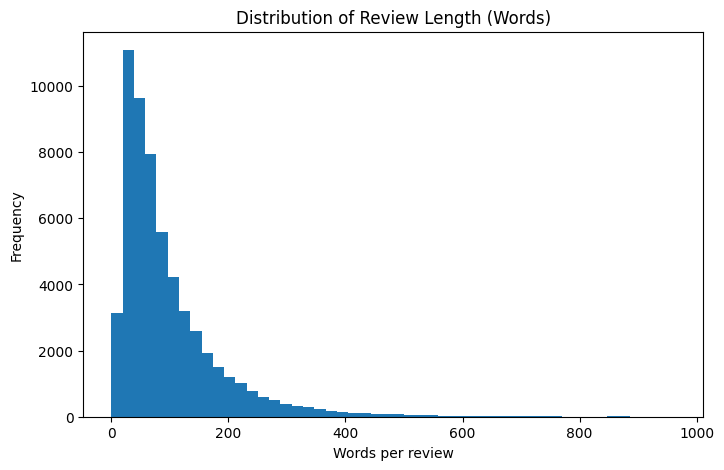

In [ ]:
# --------------------------------------------------
# Data Visualization - Distribution of Review Length
# --------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_merged["review_length_words"], bins=50)
plt.title("Distribution of Review Length (Words)")
plt.xlabel("Words per review")
plt.ylabel("Frequency")
plt.show()

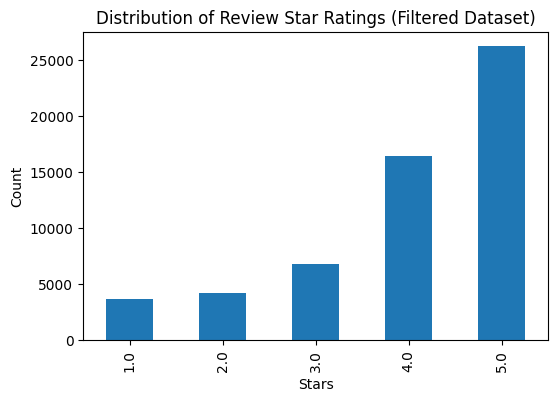

In [ ]:
# ----------------------------------------------------------
# Data Visualization - Distribution of Review Star Ratings
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
df_merged["stars_review"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Star Ratings (Filtered Dataset)")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

In [ ]:
# -----------------------------
# Unique Customers Covered
# -----------------------------
num_unique_customers = df_merged["user_id"].nunique()
print("Unique customers:", num_unique_customers)

Unique customers: 48722


In [ ]:
# -----------------------------
# Restaurants Covered
# -----------------------------
num_businesses = df_merged["business_id"].nunique()
print("Businesses covered:", num_businesses)

Businesses covered: 1853


In [ ]:
# -----------------------------
# Open vs Closed Restaurants by City
# -----------------------------

num_businesses = df_restaurants["business_id"].nunique()
num_states = df_restaurants["state"].nunique()
num_cities = df_restaurants["city"].nunique()

print("Businesses covered (restaurants):", num_businesses)
print("States covered (restaurants):", num_states)
print("Cities covered (restaurants):", num_cities)

print("\nOpen vs Closed (restaurants):")
display(df_restaurants["open"].value_counts())

print("\nTop 10 cities by # restaurants:")
display(df_restaurants["city"].value_counts().head(10))

Businesses covered (restaurants): 1853
States covered (restaurants): 14
Cities covered (restaurants): 286

Open vs Closed (restaurants):


,count
open,
1,1333
0,520



Top 10 cities by # restaurants:


,count
city,
Philadelphia,246
New Orleans,121
Tampa,114
Indianapolis,102
Nashville,98
Tucson,81
Saint Louis,73
Reno,64
Edmonton,54


In [ ]:
# -----------------------------
# Average stars per review
# -----------------------------
avg_stars_per_review = df_merged["stars_review"].mean()
print("Average stars per review:", round(avg_stars_per_review, 2))

Average stars per review: 4.0


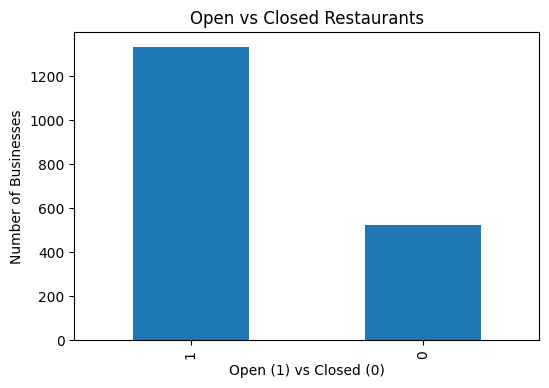

In [ ]:
# -----------------------------
# Open vs Closed Retaurants Visual
# -----------------------------
plt.figure(figsize=(6,4))
df_restaurants["open"].value_counts().plot(kind="bar")
plt.title("Open vs Closed Restaurants")
plt.xlabel("Open (1) vs Closed (0)")
plt.ylabel("Number of Businesses")
plt.show()

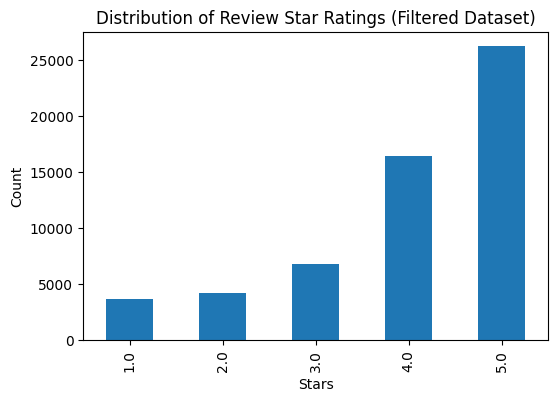

In [ ]:
# -----------------------------
# Distribution of Reviews for Restaurants Visual
# -----------------------------
plt.figure(figsize=(6,4))
df_merged["stars_review"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Star Ratings (Filtered Dataset)")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

Reviews per business (summary):


,0
count,1853.000000
mean,30.947652
std,46.847023
min,1.000000
25%,9.000000
50%,17.000000
75%,34.000000
max,950.000000


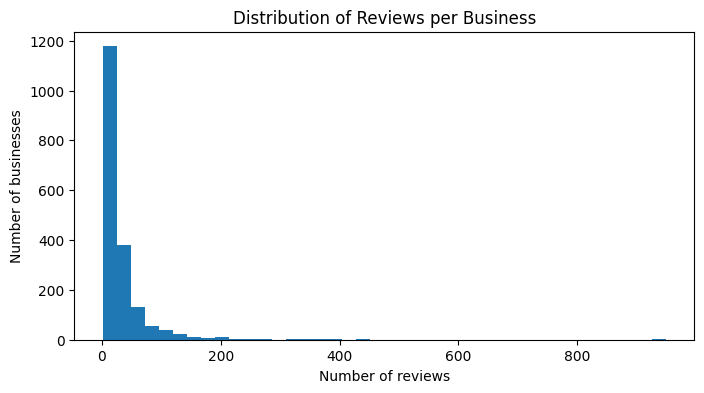

In [ ]:
# -----------------------------
# Reviews per Restaruant
# -----------------------------
reviews_per_business = df_merged.groupby("business_id").size()

print("Reviews per business (summary):")
display(reviews_per_business.describe())

plt.figure(figsize=(8,4))
plt.hist(reviews_per_business, bins=40)
plt.title("Distribution of Reviews per Business")
plt.xlabel("Number of reviews")
plt.ylabel("Number of businesses")
plt.show()

In [ ]:
# -----------------------------
# Final Summary Table
# -----------------------------
section5_summary = pd.DataFrame({
    "Metric": [
        "Number of reviews",
        "Total number of tokens",
        "Unique words / vocab size",
        "Average review length in words",
        "Number of unique customers",
        "Number of restaurants",
        "Number of states covered",
        "Number of cities covered",
        "Open restaurants count",
        "Closed restaurants count",
        "Average stars per review",
        "Average stars per restaurant"
    ],
    "Value": [
        len(df_merged),
        int(df_merged["review_length_words"].sum()),
        int(len(set([w for toks in df_merged["tokens"] for w in toks]))),
        round(df_merged["review_length_words"].mean(), 2),
        int(df_merged["user_id"].nunique()),
        int(df_restaurants["business_id"].nunique()),
        int(df_restaurants["state"].nunique()),
        int(df_restaurants["city"].nunique()),
        int((df_restaurants["open"] == 1).sum()),
        int((df_restaurants["open"] == 0).sum()),
        round(df_merged["stars_review"].mean(), 2),
        round(df_restaurants["stars"].mean(), 2)
    ]
})

section5_summary

,Metric,Value
0,Number of reviews,57346.00
1,Total number of tokens,5572421.00
2,Unique words / vocab size,48890.00
3,Average review length in words,97.17
4,Number of unique customers,48722.00
5,Number of restaurants,1853.00
6,Number of states covered,14.00
7,Number of cities covered,286.00
8,Open restaurants count,1333.00
9,Closed restaurants count,520.00


In [ ]:
# -----------------------------
# Complaint Rate per restaurant
# -----------------------------
# Complaint rate = (# of 1-2 star reviews) / (total reviews) per business
NEG_MAX = 2

total_reviews = df_merged.groupby("business_id").size()
neg_reviews = df_merged[df_merged["stars_review"] <= NEG_MAX].groupby("business_id").size()

complaint_rate = (neg_reviews / total_reviews).fillna(0).rename("complaint_rate").reset_index()

# attach business info
complaint_rate = complaint_rate.merge(
    df_restaurants[["business_id", "name", "city", "state", "open", "review_count"]],
    on="business_id",
    how="left"
)

# Top 15 "early warning" restaurants by complaint rate
complaint_rate.sort_values("complaint_rate", ascending=False).head(15)

,business_id,complaint_rate,name,city,state,open,review_count
1738,wO0NI7NkDdbT46h-TI2BtA,1.000000,Tailgate Brewery - East Nashville,Nashville,TN,1,103
979,YIcmYL_9pibsCanwtW02gw,1.000000,Xtrordinary Pizza,Indianapolis,IN,1,47
1052,_yK1bMl56fBuj2fG5lMiMQ,1.000000,Machu Picchu Peruvian Restaurant,Indianapolis,IN,1,46
1744,wi4F4NUvxn7UWHvQ1Iiz7w,0.800000,Annex,Saint Petersburg,FL,1,46
1583,rKmGMZfuJFopDcV0gZ9jkg,0.666667,Back To the 50S,Furlong,PA,0,41
393,Cpl1-0iX6N7yauiJKhpXfA,0.666667,Hong Kong Star Noodle House,Bensalem,PA,1,50
390,CinrOH8rMB2hEvPY_iFOHA,0.636364,Casselli's Ristorante,Philadelphia,PA,0,39
1325,ioxgFKdqjRowAj4dFM7VoA,0.636364,TaTa Cuban Cafe,Indianapolis,IN,0,54
766,RdDS9iOb5JJhFom1Ny4xUQ,0.625000,Slack's Hoagie Shack,Fairless Hills,PA,1,58
876,UqXyn-KwePFVhvo1rbQVVw,0.600000,Tutti Frutti,Edmonton,AB,0,30


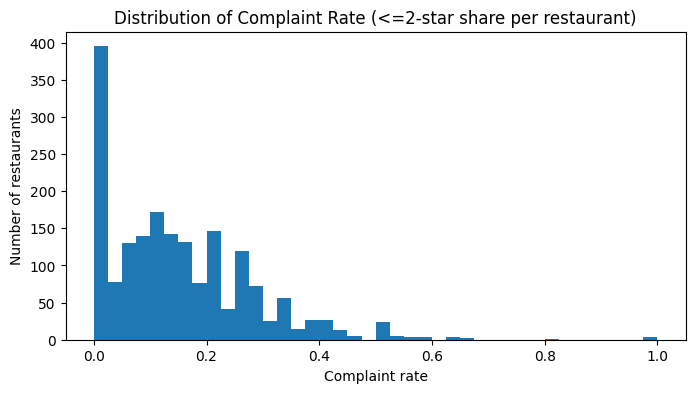

<Figure size 600x400 with 0 Axes>

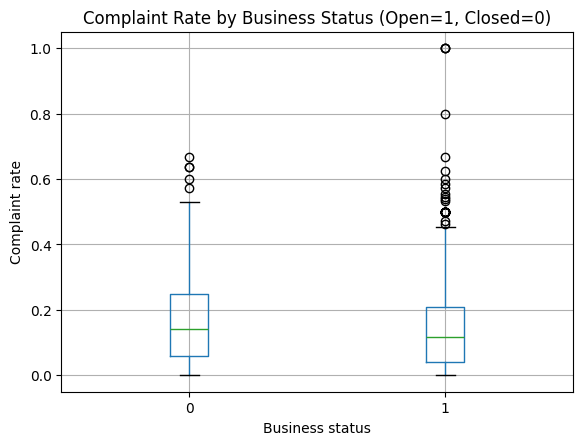

In [ ]:
# ---------------------------------
# Open vs Closed Comparison Visuals
# ---------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(complaint_rate["complaint_rate"], bins=40)
plt.title("Distribution of Complaint Rate (<=2-star share per restaurant)")
plt.xlabel("Complaint rate")
plt.ylabel("Number of restaurants")
plt.show()

plt.figure(figsize=(6,4))
complaint_rate.boxplot(column="complaint_rate", by="open")
plt.title("Complaint Rate by Business Status (Open=1, Closed=0)")
plt.suptitle("")
plt.xlabel("Business status")
plt.ylabel("Complaint rate")
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Compare average stars and complaint rate between open vs closed
# ---------------------------------------------------------------
open_closed_summary = df_restaurants.groupby("open").agg(
    avg_business_stars=("stars", "mean"),
    avg_review_count=("review_count", "mean"),
    num_businesses=("business_id", "nunique")
).reset_index()

open_closed_summary


,open,avg_business_stars,avg_review_count,num_businesses
0,0,3.871154,113.436538,520
1,1,3.945986,210.815454,1333


In [ ]:
# -------------------------------------------
# Comparing complaint rate for open vs closed
# -------------------------------------------
complaint_by_status = complaint_rate.groupby("open")["complaint_rate"].agg(["mean","median","count"]).reset_index()
complaint_by_status

,open,mean,median,count
0,0,0.165827,0.142857,520
1,1,0.141149,0.117647,1333


In [ ]:
# --------------------------------------
# Operational Issues in Negative Reviews
# --------------------------------------
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.util import ngrams
from collections import Counter

stopwords = set(ENGLISH_STOP_WORDS)
stopwords.update(["restaurant","place","food","good","great","nice","best","love","really","just","like"])

def clean_tokens(tokens):
    return [w for w in tokens if w not in stopwords and len(w) > 2]

# Ensure clean tokens exist
if "tokens_clean" not in df_merged.columns:
    df_merged["tokens_clean"] = df_merged["tokens"].apply(clean_tokens)

# Negative reviews only
neg_df = df_merged[df_merged["stars_review"] <= 2].copy()

bigrams = []
for toks in neg_df["tokens_clean"]:
    bigrams.extend(list(ngrams(toks, 2)))

top_bigrams = Counter(bigrams).most_common(20)

# Show as readable phrases
[(f"{a} {b}", c) for (a,b), c in top_bigrams]

[('customer service', 348),
 ("don't know", 269),
 ('waited minutes', 206),
 ("i'm sure", 195),
 ('minutes later', 186),
 ('took minutes', 183),
 ("don't think", 170),
 ('new orleans', 153),
 ('long time', 148),
 ('mac cheese', 145),
 ('wait staff', 139),
 ('service slow', 129),
 ('ice cream', 128),
 ('happy hour', 117),
 ("didn't want", 114),
 ('needless say', 114),
 ('pad thai', 111),
 ('looking forward', 109),
 ('decided try', 109),
 ('fried chicken', 106)]

In [ ]:
# ----------------------------------
# Compare bigrams for closed vs open
# ----------------------------------
neg_open = df_merged[(df_merged["open"] == 1) & (df_merged["stars_review"] <= 2)]
neg_closed = df_merged[(df_merged["open"] == 0) & (df_merged["stars_review"] <= 2)]

def top_bigrams_for(df, n=15):
    bg = []
    for toks in df["tokens_clean"]:
        bg.extend(list(ngrams(toks, 2)))
    top = Counter(bg).most_common(n)
    return [(f"{a} {b}", c) for (a,b), c in top]

print("Top bigrams (OPEN, <=2 stars):")
display(top_bigrams_for(neg_open, 15))

print("\nTop bigrams (CLOSED, <=2 stars):")
display(top_bigrams_for(neg_closed, 15))

Top bigrams (OPEN, <=2 stars):


[('customer service', 266),
 ("don't know", 192),
 ('waited minutes', 152),
 ("i'm sure", 127),
 ('took minutes', 125),
 ('new orleans', 122),
 ("don't think", 120),
 ('long time', 115),
 ('minutes later', 113),
 ('pad thai', 98),
 ('wait staff', 98),
 ('service slow', 93),
 ('ice cream', 90),
 ("didn't want", 85),
 ('decided try', 81)]


Top bigrams (CLOSED, <=2 stars):


[('customer service', 82),
 ('mac cheese', 79),
 ("don't know", 77),
 ('minutes later', 73),
 ("i'm sure", 68),
 ('took minutes', 58),
 ('waited minutes', 54),
 ("don't think", 50),
 ('happy hour', 46),
 ('fried chicken', 41),
 ('wait staff', 41),
 ('ice cream', 38),
 ('needless say', 36),
 ('looking forward', 36),
 ('service slow', 36)]

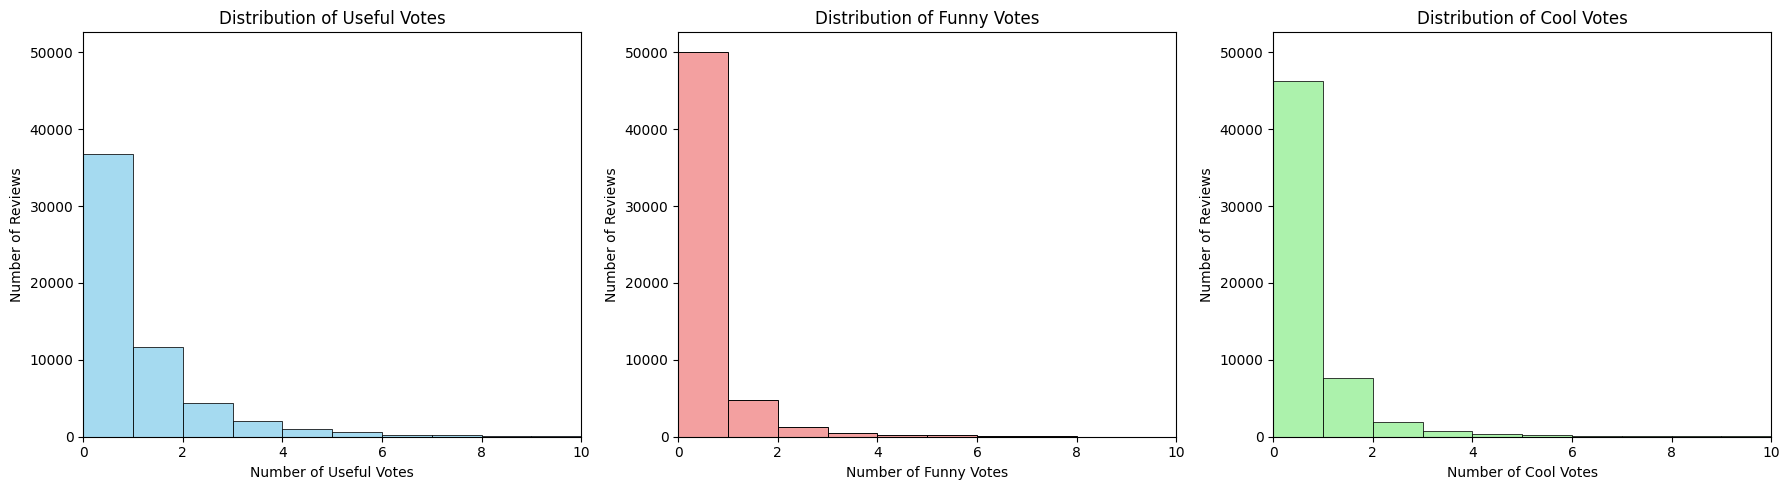

Generated histograms for 'useful', 'funny', and 'cool' vote counts.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for each vote count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate max y-limit across all histograms
max_y_limit = 0

# Distribution of Useful Votes
sns.histplot(df_merged['useful'], bins=range(int(df_merged['useful'].max()) + 2), kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Useful Votes')
axes[0].set_xlabel('Number of Useful Votes')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlim(0, 10) # Set x-axis limit
max_y_limit = max(max_y_limit, axes[0].get_ylim()[1])

# Distribution of Funny Votes
sns.histplot(df_merged['funny'], bins=range(int(df_merged['funny'].max()) + 2), kde=False, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Funny Votes')
axes[1].set_xlabel('Number of Funny Votes')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_xlim(0, 10) # Set x-axis limit
max_y_limit = max(max_y_limit, axes[1].get_ylim()[1])

# Distribution of Cool Votes
sns.histplot(df_merged['cool'], bins=range(int(df_merged['cool'].max()) + 2), kde=False, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Cool Votes')
axes[2].set_xlabel('Number of Cool Votes')
axes[2].set_ylabel('Number of Reviews')
axes[2].set_xlim(0, 10) # Set x-axis limit
max_y_limit = max(max_y_limit, axes[2].get_ylim()[1])

for ax in axes:
    ax.set_ylim(0, max_y_limit)

plt.tight_layout()
plt.show()
print("Generated histograms for 'useful', 'funny', and 'cool' vote counts.")

In [ ]:
# ============================================================
# SENTIMENT (VADER)
# ============================================================

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

# Ensure text is string
df_merged["text"] = df_merged["text"].fillna("").astype(str)

# Fast sentiment computation
texts = df_merged["text"].tolist()
df_merged["sentiment"] = [sia.polarity_scores(t)["compound"] for t in texts]

print("Sentiment column added.")
print(df_merged[["sentiment"]].describe())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Sentiment column added.
          sentiment
count  57346.000000
mean       0.753448
std        0.436216
min       -0.998800
25%        0.796400
50%        0.932700
75%        0.973700
max        0.999800


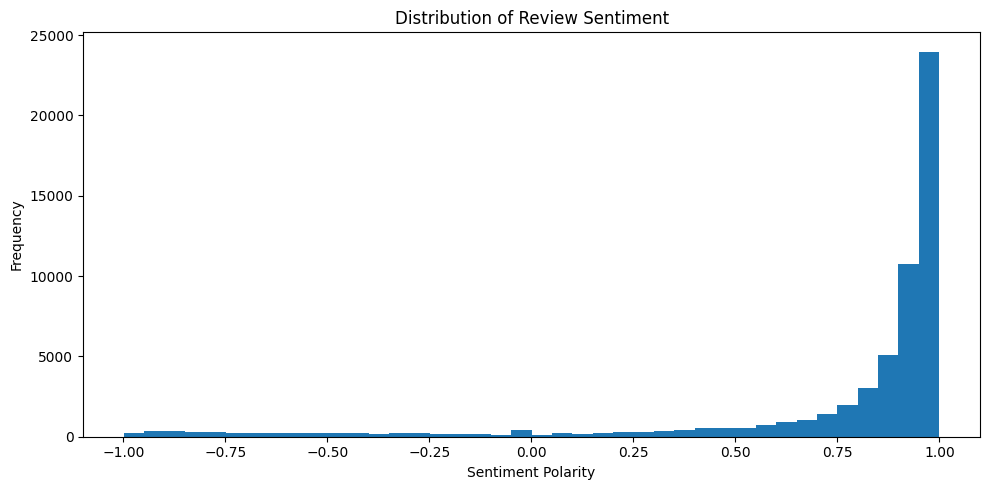

Closed    0.746
Open      0.756
Name: sentiment, dtype: float64


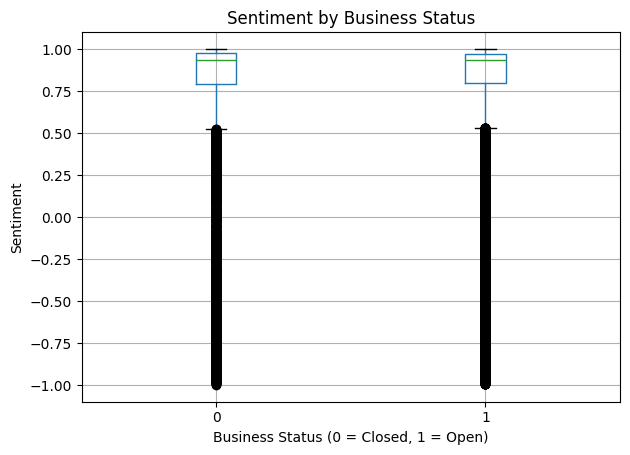

In [ ]:
# ============================================================
# PRELIMINARY SENTIMENT EDA
# ============================================================

import matplotlib.pyplot as plt

# Make sure open is consistent (0/1)
df_merged["open"] = df_merged["open"].fillna(0).astype(int)

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df_merged["sentiment"], bins=40)
plt.title("Distribution of Review Sentiment")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

avg_sentiment = df_merged.groupby("open")["sentiment"].mean()
avg_sentiment.index = ["Closed", "Open"]
print(avg_sentiment.round(3))

# Boxplot sentiment by status
df_merged.boxplot(column="sentiment", by="open")
plt.title("Sentiment by Business Status")
plt.suptitle("")
plt.xlabel("Business Status (0 = Closed, 1 = Open)")
plt.ylabel("Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
df_merged.groupby("open")["sentiment"].std()

,sentiment
open,
0,0.450551
1,0.431981


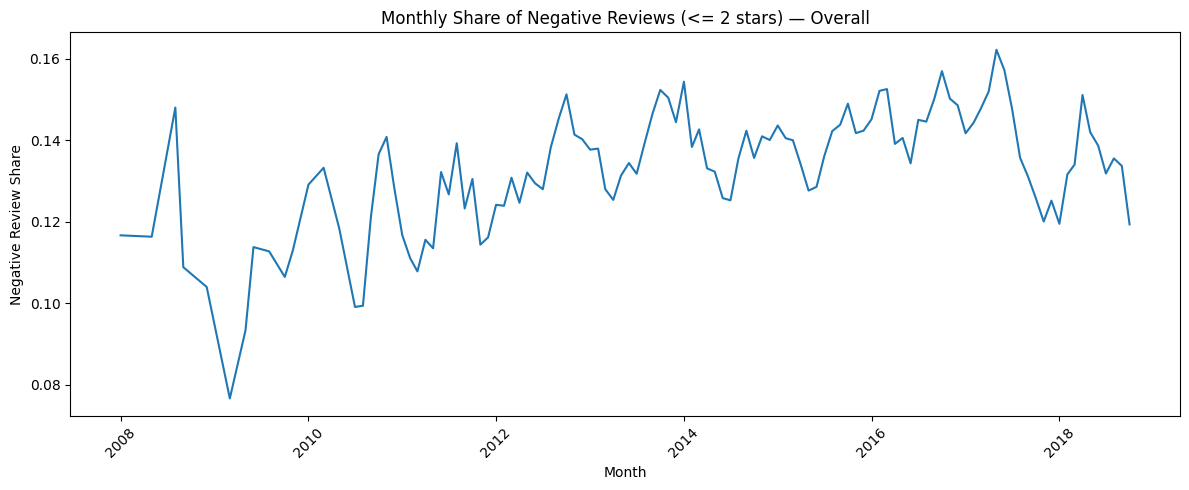

Months plotted: 116
         total_reviews  negative_reviews  negative_share
month                                                   
2018-01            647                65        0.100464
2018-02            900               135        0.150000
2018-03           1056               160        0.151515
2018-04           1002               152        0.151697
2018-05            922               113        0.122560
2018-06            854               121        0.141686
2018-07            945               124        0.131217
2018-08            793               106        0.133670
2018-09            720                98        0.136111
2018-10             34                 3        0.088235


In [ ]:
# ============================================================
# Monthly Share of Negative Reviews (<= 2 stars)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Ensure date is datetime, create month period
df_merged["month"] = pd.to_datetime(df_merged["date"], errors="coerce").dt.to_period("M")

# Negative review flag based on review-level stars
df_merged["is_negative"] = (df_merged["stars_review"] <= 2).astype(int)

# Monthly aggregation
monthly = (
    df_merged.dropna(subset=["month"])
    .groupby("month")
    .agg(
        total_reviews=("stars_review", "count"),
        negative_reviews=("is_negative", "sum")
    )
)

monthly["negative_share"] = monthly["negative_reviews"] / monthly["total_reviews"]

# Filter out low-volume months (prevents wild spikes)
MIN_MONTH_REVIEWS = 30
monthly = monthly[monthly["total_reviews"] >= MIN_MONTH_REVIEWS].copy()

# Optional smoothing (3-month rolling average)
monthly["negative_share_smooth"] = monthly["negative_share"].rolling(3).mean()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly.index.to_timestamp(), monthly["negative_share_smooth"])
plt.title("Monthly Share of Negative Reviews (<= 2 stars) — Overall")
plt.xlabel("Month")
plt.ylabel("Negative Review Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quick check
print("Months plotted:", monthly.shape[0])
print(monthly[["total_reviews", "negative_reviews", "negative_share"]].tail(10))

# Topic Modeling

In [ ]:
!pip install bertopic umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.8 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# Instantiate UMAP for dimensionality reduction
umap_model = UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)

# Instantiate HDBSCAN for clustering
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Initialize BERTopic
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

# Fit the model
all_text = df_merged['text'].tolist()
topics, probs = topic_model.fit_transform(all_text)

# Display topic info
topic_info = topic_model.get_topic_info()
print("Top 10 Topics Identified:")
print(topic_info.head(10))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
2026-03-03 22:37:45,168 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1793 [00:00<?, ?it/s]

2026-03-03 22:39:02,354 - BERTopic - Embedding - Completed ✓
2026-03-03 22:39:02,355 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 22:40:24,138 - BERTopic - Dimensionality - Completed ✓
2026-03-03 22:40:24,140 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 22:48:42,313 - BERTopic - Cluster - Completed ✓
2026-03-03 22:48:42,329 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 22:48:46,051 - BERTopic - Representation - Completed ✓


Top 10 Topics Identified:
   Topic  Count                                   Name                                     Representation  \
0     -1  29171                      -1_was_the_and_it   [was, the, and, it, we, to, of, with, for, were]   
1      0   2194                0_sushi_roll_rolls_tuna  [sushi, roll, rolls, tuna, japanese, hibachi, ...   
2      1   1928                       1_she_us_our_her  [she, us, our, her, minutes, we, he, asked, to...   
3      2   1357              2_pizza_crust_pizzas_thin  [pizza, crust, pizzas, thin, toppings, peppero...   
4      3   1021         3_burger_burgers_fries_truffle  [burger, burgers, fries, truffle, medium, bun,...   
5      4    854           4_coffee_latte_shop_espresso  [coffee, latte, shop, espresso, cafe, baristas...   
6      5    762            5_indian_naan_masala_buffet  [indian, naan, masala, buffet, tikka, paneer, ...   
7      6    678          6_donuts_donut_sliders_slider  [donuts, donut, sliders, slider, district, gla

In [ ]:
# Visualize the topics generated by the BERTopic model
topic_model.visualize_topics()

In [ ]:
import pandas as pd

# Create a DataFrame for the sampled reviews used in the topic model
df_all = df_merged.copy()

# Add the topics extracted from the model to the sampled DataFrame
df_all['topic'] = topics

# Group by 'open' status and 'topic' to see distribution
topic_counts = df_all.groupby(['open', 'topic']).size().reset_index(name='count')

# Calculate percentages within each group (Open vs Closed)
total_counts = df_all.groupby('open').size()
topic_counts['percentage'] = topic_counts.apply(lambda x: (x['count'] / total_counts[x['open']]) * 100, axis=1)

# Get topic names for readability
topic_names = topic_model.get_topic_info()[['Topic', 'Name']]
topic_counts = topic_counts.merge(topic_names, left_on='topic', right_on='Topic').drop(columns=['Topic'])

print()
display(topic_counts.sort_values(by=['open', 'percentage'], ascending=[True, False]).head(10))

,open,topic,count,percentage,Name
0,0,-1,6654,51.891133,-1_was_the_and_it
2,0,1,509,3.969430,1_she_us_our_her
1,0,0,464,3.618498,0_sushi_roll_rolls_tuna
3,0,2,361,2.815254,2_pizza_crust_pizzas_thin
4,0,3,319,2.487717,3_burger_burgers_fries_truffle
6,0,5,307,2.394136,5_indian_naan_masala_buffet
13,0,12,178,1.388131,12_bbq_brisket_ribs_pulled
5,0,4,149,1.161975,4_coffee_latte_shop_espresso
9,0,8,134,1.044997,8_vegan_vegetarian_options_hipcityveg
14,0,13,113,0.881229,13_brunch_sunday_eggs_benedict


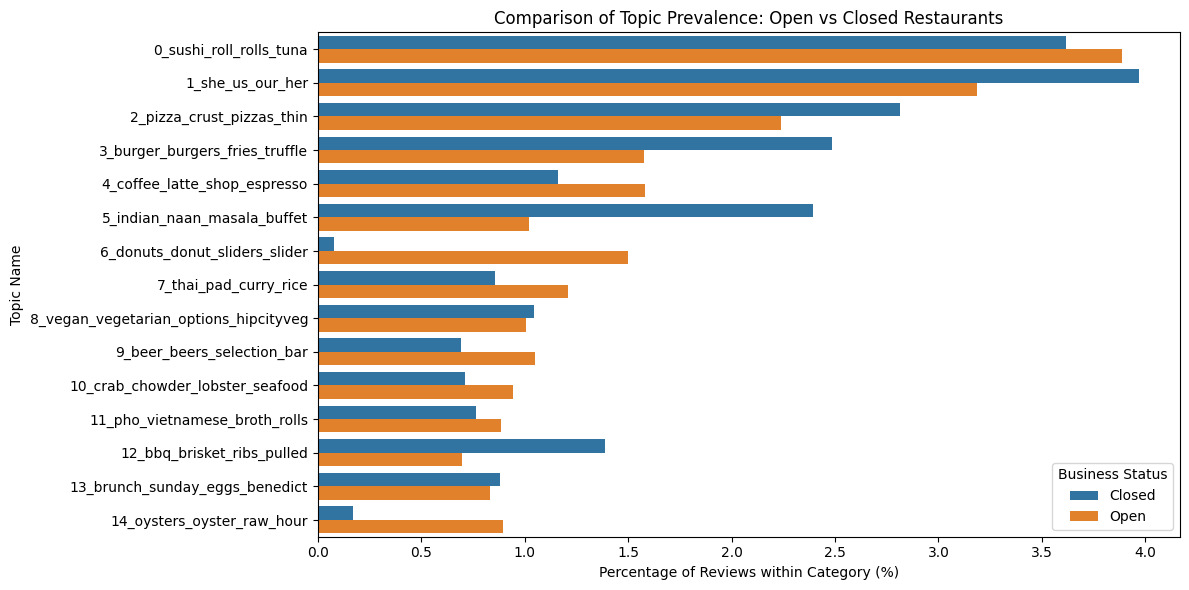

Topics with higher prevalence in CLOSED restaurants:


,Closed_Pct,Open_Pct,Diff
Name,,,
5_indian_naan_masala_buffet,2.394136,1.021944,1.372192
-1_was_the_and_it,51.891133,50.573861,1.317272
3_burger_burgers_fries_truffle,2.487717,1.576713,0.911004
1_she_us_our_her,3.969430,3.187117,0.782313
36_ramen_cheu_broth_noodles,0.818841,0.128024,0.690817
12_bbq_brisket_ribs_pulled,1.388131,0.698515,0.689615
2_pizza_crust_pizzas_thin,2.815254,2.237046,0.578208
69_dog_dogs_hot_diggity,0.428917,0.031444,0.397472
93_sbraga_foie_gras_course,0.366529,0.011230,0.355299


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to top N topics for clarity in visualization (excluding outlier topic -1)
top_topics_to_show = 15
top_n_topics = topic_info.iloc[1:top_topics_to_show+1]['Topic'].tolist()
plot_df = topic_counts[topic_counts['topic'].isin(top_n_topics)].copy()

# Map status to readable labels
plot_df['Status'] = plot_df['open'].map({1: 'Open', 0: 'Closed'})

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='percentage', y='Name', hue='Status')
plt.title('Comparison of Topic Prevalence: Open vs Closed Restaurants')
plt.xlabel('Percentage of Reviews within Category (%)')
plt.ylabel('Topic Name')
plt.legend(title='Business Status')
plt.tight_layout()
plt.show()

# Identify topics with higher prevalence in closed restaurants
closure_prevalence = topic_counts.pivot(index='Name', columns='open', values='percentage').fillna(0)
closure_prevalence.columns = ['Closed_Pct', 'Open_Pct']
closure_prevalence['Diff'] = closure_prevalence['Closed_Pct'] - closure_prevalence['Open_Pct']

print("Topics with higher prevalence in CLOSED restaurants:")
display(closure_prevalence[closure_prevalence['Diff'] > 0].sort_values(by='Diff', ascending=False).head(10))

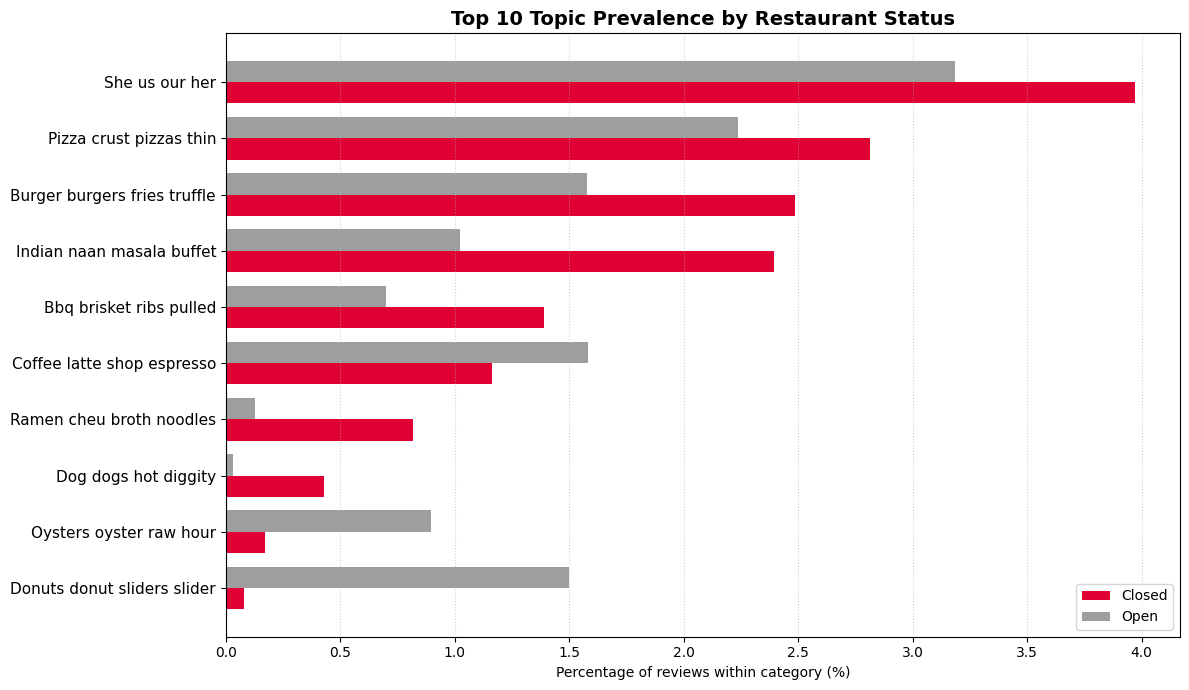

In [ ]:
# Top 10 Topic Prevalence: Open vs Closed Restaurants
# - Uses red (Closed) and gray (Open)
# - Selects Top N topics by absolute prevalence gap
# - Sorts display by Closed prevalence (easier to read in a presentation)
# - Polished labels + title formatting

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 10  # change to 8, 9, or 10 if you want

# ---- INPUT ----
# Expect df_topics (or topic_counts) with columns:
#   open (0=Closed, 1=Open), Name (topic label), percentage (topic prevalence)
# If your df is named topic_counts, this will work as-is:
df_topics = topic_counts.copy()

# Drop noise topic if present (common with BERTopic)
if "topic" in df_topics.columns:
    df_topics = df_topics[df_topics["topic"] != -1].copy()

# Ensure percentage is numeric
df_topics["percentage"] = pd.to_numeric(df_topics["percentage"], errors="coerce")

# Pivot to wide form: Closed_pct and Open_pct
wide = (
    df_topics.pivot_table(
        index=["Name"],
        columns="open",
        values="percentage",
        aggfunc="first"
    )
    .rename(columns={0: "Closed_pct", 1: "Open_pct"})
    .reset_index()
)

# Keep only rows where both exist
wide = wide.dropna(subset=["Closed_pct", "Open_pct"]).copy()

def clean_topic_label(s: str) -> str:
    s = str(s)
    s = re.sub(r"^\-?\d+_", "", s)     # remove leading "0_" or "-1_"
    s = s.replace("_", " ").strip()    # underscores -> spaces
    s = re.sub(r"\s+", " ", s)
    return s[:1].upper() + s[1:] if s else s

# Compute gap and select Top N by absolute gap
wide["Gap_closed_minus_open"] = wide["Closed_pct"] - wide["Open_pct"]
wide["AbsGap"] = wide["Gap_closed_minus_open"].abs()

plot_df = wide.sort_values("AbsGap", ascending=False).head(TOP_N).copy()
plot_df["Label"] = plot_df["Name"].apply(clean_topic_label)

# RECOMMENDED: sort for display by Closed prevalence (cleaner visual flow)
plot_df = plot_df.sort_values("Closed_pct", ascending=True).reset_index(drop=True)

# Plot: grouped horizontal bars
y = np.arange(len(plot_df))
bar_h = 0.38

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(y - bar_h/2, plot_df["Closed_pct"], height=bar_h, color="#E00034", label="Closed")  # red
ax.barh(y + bar_h/2, plot_df["Open_pct"],   height=bar_h, color="#9e9e9e", label="Open")    # gray

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Label"])
ax.set_xlabel("Percentage of reviews within category (%)")
ax.set_title("Top 10 Topic Prevalence by Restaurant Status", fontsize=14, weight="bold")
ax.tick_params(axis="y", labelsize=11)

ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.6)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

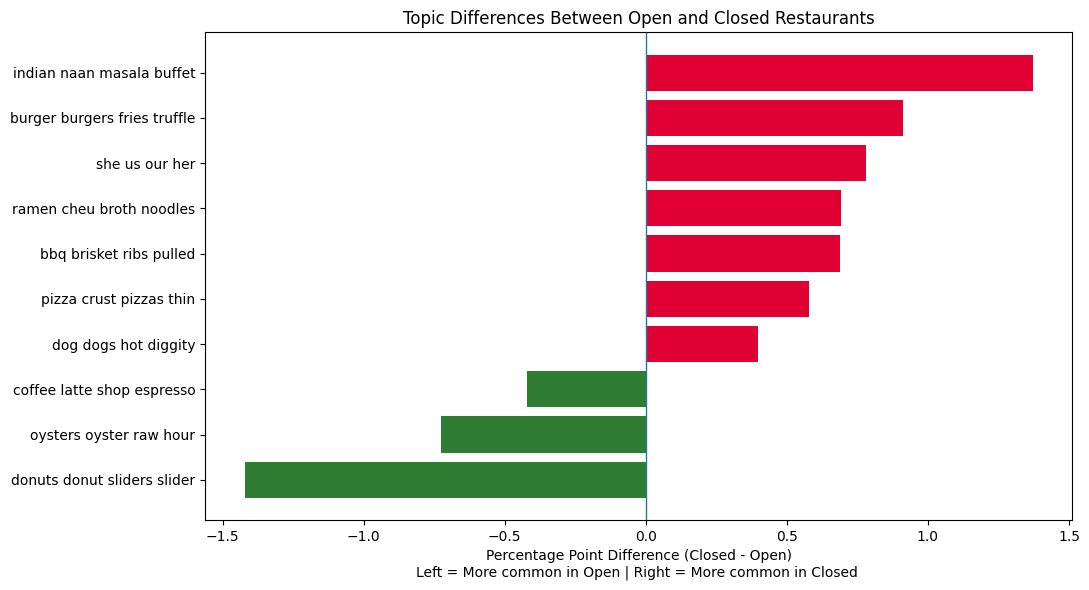

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy topic counts
df_topics = topic_counts.copy()

# Remove BERTopic noise topic
df_topics = df_topics[df_topics["topic"] != -1].copy()

# Convert to wide format
wide = df_topics.pivot_table(
    index=["topic", "Name"],
    columns="open",
    values="percentage",
    aggfunc="first"
).reset_index()

# Rename columns
wide = wide.rename(columns={0: "Closed_pct", 1: "Open_pct"}).dropna(subset=["Closed_pct", "Open_pct"])

# Ensure numeric
wide["Closed_pct"] = pd.to_numeric(wide["Closed_pct"], errors="coerce")
wide["Open_pct"] = pd.to_numeric(wide["Open_pct"], errors="coerce")

# Calculate difference (Closed - Open)
wide["Diff_closed_minus_open"] = wide["Closed_pct"] - wide["Open_pct"]

# Absolute difference for selecting top topics
wide["abs_diff"] = wide["Diff_closed_minus_open"].abs()

# Select top 10 most different topics
plot_df = wide.sort_values("abs_diff", ascending=False).head(10).copy()

# Clean topic labels
plot_df["Label"] = (
    plot_df["Name"]
    .str.replace(r"^\-?\d+_", "", regex=True)
    .str.replace("_", " ")
)

# Sort so Open-heavy appear on left, Closed-heavy on right
plot_df = plot_df.sort_values("Diff_closed_minus_open")

# Colors
colors = ["#E00034" if x > 0 else "#2E7D32" for x in plot_df["Diff_closed_minus_open"]]

# Plot
plt.figure(figsize=(11,6))

plt.barh(
    plot_df["Label"],
    plot_df["Diff_closed_minus_open"],
    color=colors
)

plt.axvline(0, linewidth=1)

plt.title("Topic Differences Between Open and Closed Restaurants")

plt.xlabel(
    "Percentage Point Difference (Closed - Open)\n"
    "Left = More common in Open | Right = More common in Closed "
)

plt.tight_layout()
plt.show()

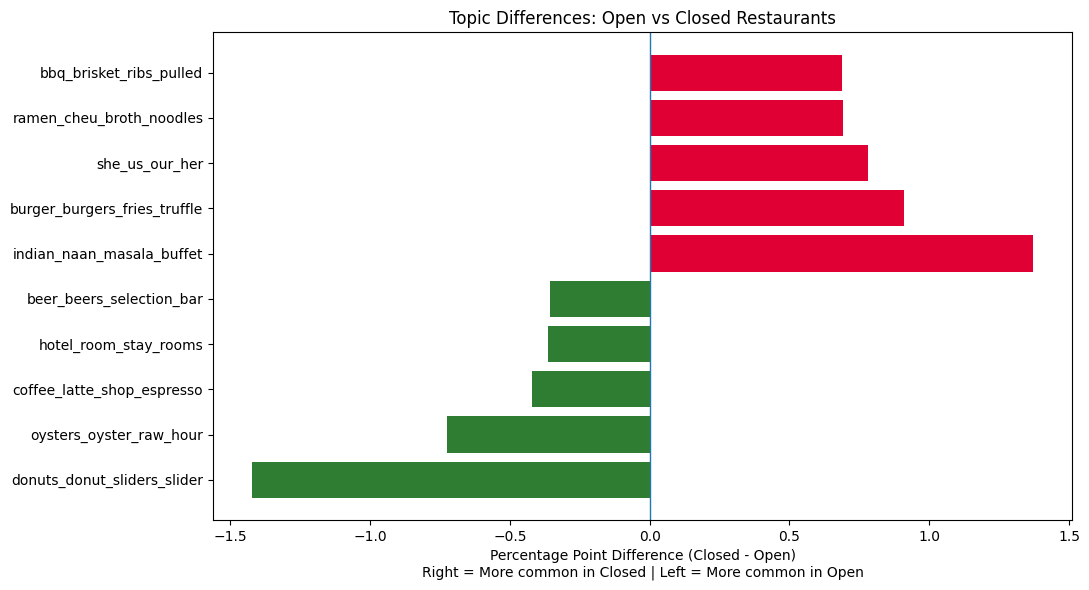

In [ ]:
plt.figure(figsize=(11, 6))

# Create color list based on sign of difference
colors = ["#E00034" if x > 0 else "#2E7D32" for x in plot_df["Diff_closed_minus_open"]]

plt.barh(
    plot_df["Label"],
    plot_df["Diff_closed_minus_open"],
    color=colors
)

plt.axvline(0, linewidth=1)

plt.title("Topic Differences: Open vs Closed Restaurants")
plt.xlabel("Percentage Point Difference (Closed - Open)\nRight = More common in Closed | Left = More common in Open")

plt.tight_layout()
plt.show()
plot_df = plot_df.sort_values("Diff_closed_minus_open")

In [ ]:
avg_diff = plot_df["Diff_closed_minus_open"].abs().mean()
max_diff = plot_df["Diff_closed_minus_open"].abs().max()

print("Average absolute difference:", round(avg_diff, 3))
print("Maximum difference:", round(max_diff, 3))

Average absolute difference: 0.774
Maximum difference: 1.422


# Time-to-Decline Patterns

In [ ]:
# Filter for closed businesses
df_closed = df_merged[df_merged['open'] == 0].copy()

# Extract year and month for temporal analysis
df_closed['year_month'] = df_closed['date'].dt.to_period('M')

# Use the fitted topic model to transform reviews of closed businesses
closed_texts = df_closed['text'].tolist()

# Assign topics to all closed business reviews to get a complete temporal picture
closed_topics, _ = topic_model.transform(closed_texts)
df_closed['topic'] = closed_topics

# Map topic names for better interpretation
topic_names_map = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()
df_closed['topic_name'] = df_closed['topic'].map(topic_names_map)

Batches:   0%|          | 0/401 [00:00<?, ?it/s]

2026-03-03 22:49:13,305 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-03 22:49:37,286 - BERTopic - Dimensionality - Completed ✓
2026-03-03 22:49:37,287 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-03 22:49:38,880 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-03-03 22:51:33,291 - BERTopic - Probabilities - Completed ✓
2026-03-03 22:51:33,292 - BERTopic - Cluster - Completed ✓


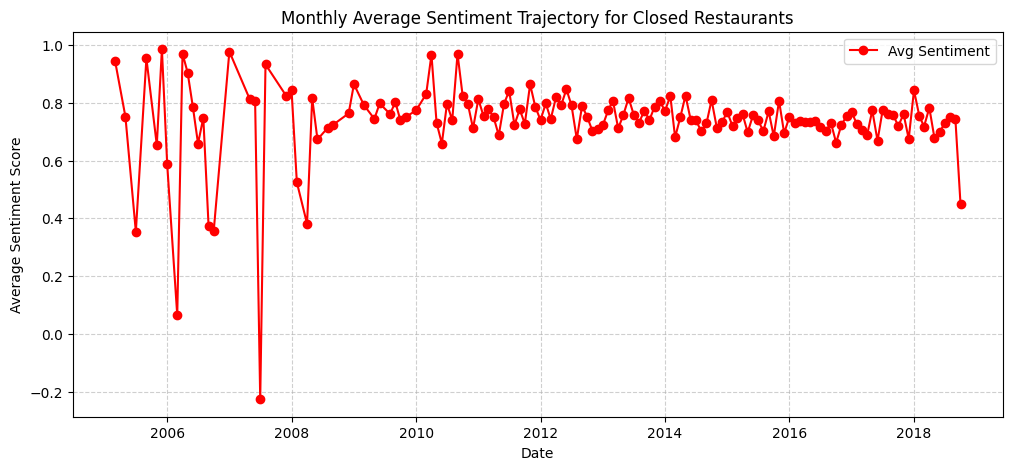

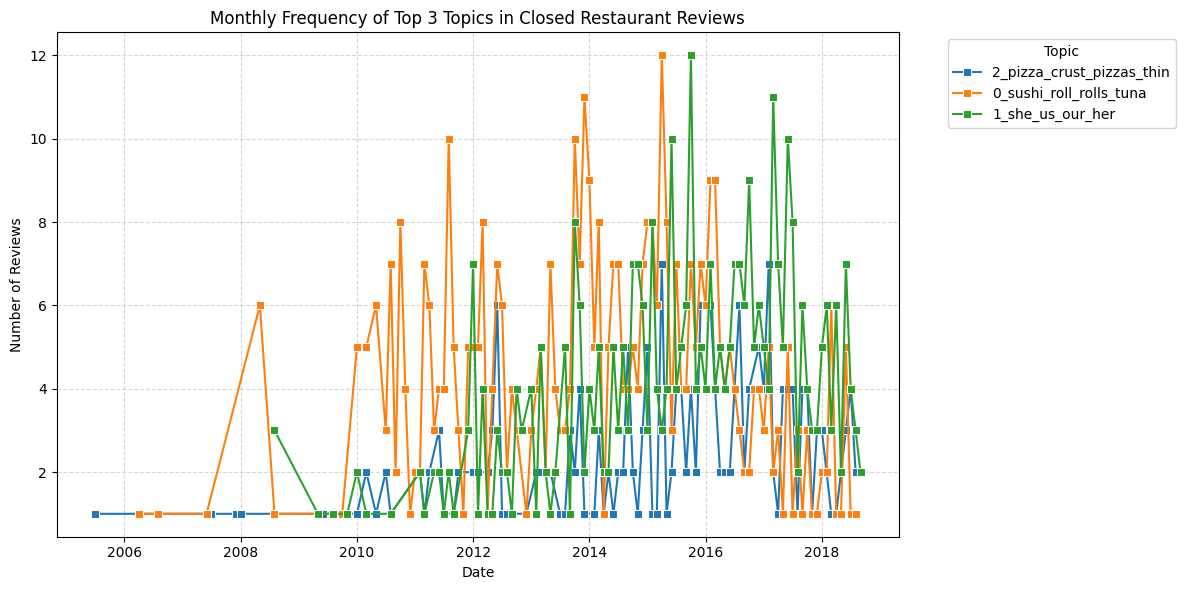

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year_month for overall sentiment trend
temporal_sentiment = df_closed.groupby('year_month')['sentiment'].mean().reset_index()
temporal_sentiment['timestamp'] = temporal_sentiment['year_month'].dt.to_timestamp()

# Plot overall sentiment trajectory
plt.figure(figsize=(12, 5))
plt.plot(temporal_sentiment['timestamp'], temporal_sentiment['sentiment'], marker='o', color='red', label='Avg Sentiment')
plt.title('Monthly Average Sentiment Trajectory for Closed Restaurants')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Identify top 3 topics from closure_prevalence (excluding outliers)
top_closed_topics_names = closure_prevalence.sort_values(by='Closed_Pct', ascending=False).index[1:4].tolist()

# Calculate monthly frequency for these specific topics
topic_trends = df_closed[df_closed['topic_name'].isin(top_closed_topics_names)].groupby(['year_month', 'topic_name']).size().reset_index(name='count')
topic_trends['timestamp'] = topic_trends['year_month'].dt.to_timestamp()

# Plot topic frequency over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=topic_trends, x='timestamp', y='count', hue='topic_name', marker='s')
plt.title('Monthly Frequency of Top 3 Topics in Closed Restaurant Reviews')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
closed_df = df_merged[df_merged["open"] == 0].copy()

closed_df["year_month"] = pd.to_datetime(closed_df["date"]).dt.to_period("M")

monthly_sentiment = closed_df.groupby("year_month")["sentiment"].mean().reset_index()

# Split early vs late
cutoff = monthly_sentiment["year_month"].max() - 24

early_period = monthly_sentiment[monthly_sentiment["year_month"] <= cutoff]
late_period = monthly_sentiment[monthly_sentiment["year_month"] > cutoff]

print("Early Avg:", early_period["sentiment"].mean())
print("Late Avg:", late_period["sentiment"].mean())

Early Avg: 0.741051470586608
Late Avg: 0.7251159186606054


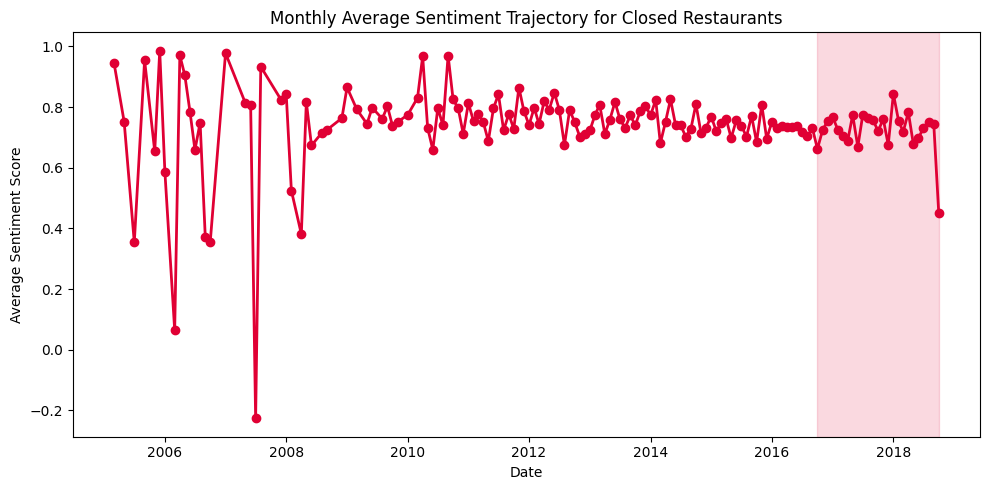

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Period to datetime for plotting
monthly_sentiment["year_month_dt"] = monthly_sentiment["year_month"].dt.to_timestamp()

# Define final 24-month cutoff date
cutoff_date = monthly_sentiment["year_month_dt"].max() - pd.DateOffset(months=24)

plt.figure(figsize=(10,5))

# Plot sentiment line in Yelp red
plt.plot(monthly_sentiment["year_month_dt"],
         monthly_sentiment["sentiment"],
         color="#E00034",
         marker="o",
         linewidth=2)

# Shade final 24 months
plt.axvspan(cutoff_date,
            monthly_sentiment["year_month_dt"].max(),
            color="#E00034",
            alpha=0.15)

plt.title("Monthly Average Sentiment Trajectory for Closed Restaurants")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")

plt.tight_layout()
plt.show()

In [4]:
# Transform all reviews in df_merged to get topic probabilities
all_texts = df_merged['text'].tolist()

# This gives us the probability of each review belonging to each topic
_, probs = topic_model.transform(all_texts)

# Create a DataFrame from the probabilities
topic_cols = [f'topic_{i}' for i in range(probs.shape[1])]
df_probs = pd.DataFrame(probs, columns=topic_cols, index=df_merged.index)

# Combine sentiment, topic probabilities, and target variable
df_model = pd.concat([df_merged[['sentiment', 'open']], df_probs], axis=1)

# Prepare features (X) and target (y)
X = df_model.drop(columns=['open'])
y = df_model['open']

NameError: name 'df_merged' is not defined

### Predictive Modeling: Random Forest

We trained a Random Forest classifier to evaluate whether sentiment, topic prevalence, and complaint rate features can distinguish open vs closed restaurants.

Due to class imbalance (approximately 77% open, 23% closed), we applied class_weight="balanced".

Evaluation includes accuracy, precision, recall, and confusion matrix.

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
# Using class_weight='balanced' because of the class imbalance (77% Open, 23% Closed)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model performance
print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features

plt.figure(figsize=(10, 8))
plt.title('Top 15 Important Features for Predicting Closure')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

NameError: name 'X' is not defined